In [ ]:
from jax import config

config.update("jax_enable_x64", True)

import os

os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.9"

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import jax.numpy as jnp
from jax import jit, random, lax, vmap
import argparse
from tqdm import tqdm

from scipy.optimize import fsolve, minimize, curve_fit
from scipy.interpolate import CubicSpline, splrep, splev, UnivariateSpline
from scipy.signal import savgol_filter

from mpl_toolkits.axes_grid1 import make_axes_locatable

plt.rcParams.update(
    {
        "mathtext.fontset": "stix",
        "font.family": "STIXGeneral",
        "legend.fontsize": 16,  # this is the font size in legends
        "xtick.labelsize": 16,  # this and next are the font of ticks
        "ytick.labelsize": 16,
        "axes.titlesize": 16,
        "axes.labelsize": 24,  # this is the fonx of axes labels
        "savefig.format": "pdf",  # how figures should be saved
        "legend.edgecolor": "0.0",
        "legend.framealpha": 1.0,
    }
)


plasmamap = plt.get_cmap("plasma")
virimap = plt.cm.viridis

In [2]:
parser = argparse.ArgumentParser(description="ZTS_radial_v1_debug")

# parameters for the grid
parser.add_argument("--Lx", type=float, default=30, help="radial domain size")
parser.add_argument("--Lz", type=float, default=30, help="vertical domain size")
parser.add_argument(
    "--nx", type=int, default=64, help="number of points in the radial direction"
)
parser.add_argument(
    "--nz", type=int, default=64, help="number of points in the vertical direction"
)

# interaction parameters
parser.add_argument(
    "--chi-psi", type=float, default=0.0, help="chi parameter for psi (membrane)"
)
parser.add_argument(
    "--chi-phi", type=float, default=2.5, help="chi parameter for phi (bulk)"
)
parser.add_argument(
    "--lmda-phi", type=float, default=1.0, help="gradient coefficient for phi (bulk)"
)
parser.add_argument(
    "--lmda-psi",
    type=float,
    default=1.0,
    help="gradient coefficient for psi (membrane)",
)
parser.add_argument(
    "--h0",
    type=float,
    default=-0.2,
    help="coupling coefficient between phi and the bare membrane",
)
parser.add_argument(
    "--h-phi-psi",
    type=float,
    default=2.0,
    help="coupling coefficient between phi and psi",
)

# mobility coefficients
parser.add_argument(
    "--m-phi", type=float, default=1.0, help="mobility coefficient for phi"
)
parser.add_argument(
    "--m-psi", type=float, default=1.0, help="mobility coefficient for psi"
)
parser.add_argument("--dt", type=float, default=1e-4, help="time step size")


# bulk tether concentration
parser.add_argument(
    "--psi-bulk", type=float, default=0.05, help="bulk tether concentration"
)

## number of steps
parser.add_argument("--n-epoch", type=int, default=200, help="number of epochs")
parser.add_argument(
    "--n-steps-per-epoch", type=int, default=200000, help="number of steps per epoch"
)

parser.add_argument(
    "--init-profile",
    type=str,
    default=None,
    help="initial profile for phi and psi",
)

parser.add_argument(
    "--outputdir",
    type=str,
    default="data_tether_junction_v2_test/",
    help="output directory",
)
flags = parser.parse_args("")

chi_psi, chi_phi = flags.chi_psi, flags.chi_phi
lmda_phi, lmda_psi = flags.lmda_phi, flags.lmda_psi
h0, h_phi_psi = flags.h0, flags.h_phi_psi
M_phi, M_psi = flags.m_phi, flags.m_psi
psi_boundary = flags.psi_bulk

In [3]:
########################################################################################
# construct the grid

dz = flags.Lz / flags.nz
dx = flags.Lx / flags.nx

x_center = dx / 2 + jnp.arange(flags.nx) * dx
z_center = dz / 2 + jnp.arange(flags.nz) * dz


def plot_profile(phi, psi_x, psi_z, axes=None, vmin=None, vmax=None):
    fig, ax_img = plt.subplots(figsize=(6, 5), tight_layout=True)
    c = ax_img.imshow(
        phi,
        origin="lower",
        # aspect="auto",
        extent=(0, flags.Lx, 0, flags.Lz),
        cmap=plasmamap,
        vmin=vmin,
        vmax=vmax,
    )

    # create side / bottom axes that hug the image axes exactly
    divider = make_axes_locatable(ax_img)
    ax_x = divider.append_axes("bottom", size="20%", pad=0.5, sharex=ax_img)
    ax_z = divider.append_axes("left", size="20%", pad=0.5, sharey=ax_img)

    # Create the second subplot
    ax_x.plot(x_center, psi_x)
    ax_x.set_xlabel("$x$")
    ax_x.set_ylabel("$\psi$")
    ax_x.set_ylim(0, None)

    # Create the second subplot
    ax_z.plot(psi_z, z_center)
    ax_z.set_ylabel("$z$")
    ax_z.set_xlabel("$\psi$")
    ax_z.set_xlim(0, None)

    # Add the colorbar to the top of the first subplot
    cb = fig.colorbar(
        c,
        ax=ax_img,
        orientation="vertical",
        location="right",
        label="$\phi$",
        aspect=50,
    )

    return fig, (ax_img, ax_x, ax_z)


phi_tol = 1e-8


def calc_f_entropy(psi):
    return psi * jnp.log(jnp.clip(psi, phi_tol, 1.0 - phi_tol)) + (1 - psi) * jnp.log(
        jnp.clip(1.0 - psi, phi_tol, 1.0 - phi_tol)
    )


def calc_f_uniform(psi, chi_psi):
    return calc_f_entropy(psi) + chi_psi * psi * (1 - psi)


def loss_sphere(c_path, R0, cos_theta):
    z0 = -R0 * cos_theta * np.sign(1 / np.sqrt(2) - cos_theta)
    return np.sum(((c_path[:, 0] - z0) ** 2 + (c_path[:, 1] - z0) ** 2 - R0**2) ** 2)


def measure_contact_angle_fit(phi, phi_threshold, psi_x=None, psi_z=None):
    # use the contour generated by the contour function; also does not work super well...
    if psi_x is None:
        psi_x = np.zeros(phi.shape[1])
    if psi_z is None:
        psi_z = np.zeros(phi.shape[0])

    fig, (ax_img, ax_x, ax_z) = plot_profile(phi, psi_x, psi_z)
    c = ax_img.contour(
        x_center,
        z_center,
        phi,
        levels=[phi_threshold],
        colors="k",
        linestyles="--",
    )
    c_path = c.allsegs[0][0]
    c_path = c_path[np.argsort(-c_path[:, 0])]

    fitres_sphere = minimize(
        lambda x: loss_sphere(c_path, x[0], x[1]),
        x0=[flags.Lz, 0],
        method="Nelder-Mead",
        bounds=((0, flags.Lz * 50), (-1, 1 / np.sqrt(2))),
    )
    fitres_sphere_2 = minimize(
        lambda x: loss_sphere(c_path, x[0], x[1]),
        x0=[flags.Lz, 1],
        method="Nelder-Mead",
        bounds=((0, flags.Lz * 50), (1 / np.sqrt(2), 1)),
    )
    if fitres_sphere.fun > fitres_sphere_2.fun:
        fitres_sphere = fitres_sphere_2

    R0 = fitres_sphere.x[0]
    cos_theta = fitres_sphere.x[1]
    z0 = -R0 * cos_theta * np.sign(1 / np.sqrt(2) - cos_theta)
    # print(z0, R0)
    # if there are two intersections, take the larger one
    if z0 > R0 / np.sqrt(2):
        # print(cos_theta)
        cos_theta = -np.abs(cos_theta)
        # print("Flipping cos_theta to", cos_theta)

    x_fit = np.linspace(0, flags.Lx, 100)
    z_fit = z0 + np.sqrt(R0**2 - (x_fit - z0) ** 2) * np.sign(
        1 / np.sqrt(2) - cos_theta
    )
    plot_mask = np.bitwise_and(z_fit >= 0, z_fit <= flags.Lz)
    x_fit = x_fit[plot_mask]
    z_fit = z_fit[plot_mask]
    ax_img.plot(x_fit, z_fit, "r--")
    r_contact = z0 + R0 * np.sin(np.arccos(cos_theta)) * np.sign(
        1 / np.sqrt(2) - cos_theta
    )

    return r_contact, cos_theta, (fig, (ax_img, ax_x, ax_z))


########################################################################################
# determine binodal concentration
def convex_hull_1d(points):
    points = points[np.argsort(points[:, 0])]  # Sort by x-coordinates

    def cross(o, a, b):
        """2D cross product of OA and OB vectors (z-component)."""
        return (a[0] - o[0]) * (b[1] - o[1]) - (a[1] - o[1]) * (b[0] - o[0])

    # Build lower hull
    lower = []
    for p in points:
        while len(lower) >= 2 and cross(lower[-2], lower[-1], p) <= 0:
            lower.pop()
        lower.append(tuple(p))

    return np.array(lower)


def calc_binodal_spinodal(psi_mesh, f_mesh):
    xdata, ydata = psi_mesh, f_mesh

    # find the lower hull of the free energy
    points = np.column_stack((xdata, ydata))
    lower_hull = convex_hull_1d(points)

    # find binodal by comparing  free energy
    xmesh = np.linspace(psi_mesh[0], psi_mesh[-1], 1000)
    yinterp = np.interp(xmesh, xdata, ydata)
    yinterp_hull = np.interp(xmesh, lower_hull[:, 0], lower_hull[:, 1])

    df_threshold = 1e-8
    binodal_region = yinterp_hull < yinterp - df_threshold
    # find first and last non-zero region
    binodal_region_idx = np.where(binodal_region)[0]
    if len(binodal_region_idx) == 0:
        return [np.nan, np.nan], [np.nan, np.nan]

    psi_binodal = [xmesh[binodal_region_idx[0]], xmesh[binodal_region_idx[-1]]]

    # to determine spinodal, we need to compute the inflection point
    free_energy_derivative2 = CubicSpline(
        xdata,
        savgol_filter(ydata, window_length=5, polyorder=3, deriv=2)
        / (xdata[1] - xdata[0]) ** 2,
    )
    xmesh = np.linspace(psi_binodal[0], psi_binodal[1], 100)[1:-1]
    spinodal_region = free_energy_derivative2(xmesh) < 0
    spinodal_region_idx = np.where(spinodal_region)[0]
    if len(spinodal_region_idx) == 0:
        psi_spinodal = [np.nan, np.nan]
    psi_spinodal = [xmesh[spinodal_region_idx[0]], xmesh[spinodal_region_idx[-1]]]
    return psi_binodal, psi_spinodal

<>:31: SyntaxWarning: invalid escape sequence '\p'
<>:37: SyntaxWarning: invalid escape sequence '\p'
<>:46: SyntaxWarning: invalid escape sequence '\p'
<>:31: SyntaxWarning: invalid escape sequence '\p'
<>:37: SyntaxWarning: invalid escape sequence '\p'
<>:46: SyntaxWarning: invalid escape sequence '\p'
/var/folders/mq/p5kn27bn3j927psc4z_49npm0000gn/T/ipykernel_71893/1784356733.py:31: SyntaxWarning: invalid escape sequence '\p'
  ax_x.set_ylabel("$\psi$")
/var/folders/mq/p5kn27bn3j927psc4z_49npm0000gn/T/ipykernel_71893/1784356733.py:37: SyntaxWarning: invalid escape sequence '\p'
  ax_z.set_xlabel("$\psi$")
/var/folders/mq/p5kn27bn3j927psc4z_49npm0000gn/T/ipykernel_71893/1784356733.py:46: SyntaxWarning: invalid escape sequence '\p'
  label="$\phi$",


In [4]:
phi_mesh = np.linspace(0, 1, 100)
f_phi_mesh = calc_f_uniform(phi_mesh, chi_phi)
phi_binodal, phi_spinodal = calc_binodal_spinodal(phi_mesh, f_phi_mesh)
phi_boundary = min(phi_binodal)
phi_binodal_center = (phi_binodal[0] + phi_binodal[1]) / 2

---

# Load data

In [5]:
input_folder = "../data/data_tether_junction_v2_2"

m_psi_list = np.sort(np.array([0.0, 0.1, 1.0]))

input_folder_name_all = [
    input_folder
    + f"/chi_psi_{chi_psi}_chi_phi_{chi_phi}_h0_{h0}_h1_{h_phi_psi}/"
    + f"psi_{psi_boundary:.3f}_m_psi_{M_psi:.3f}/"
    for M_psi in m_psi_list
]

output_folder = "fig2/"
os.makedirs(output_folder, exist_ok=True)

In [6]:
def calc_mean_r2(phi):
    r_center = np.sqrt(x_center**2 + z_center[:, np.newaxis] ** 2)
    return np.sum(phi * r_center**2 * dx * dz) / np.sum(phi * dx * dz)


def calc_mean_r(phi, phi_background=0.0):
    r_center = np.sqrt(x_center**2 + z_center[:, np.newaxis] ** 2)
    return np.sum((phi - phi_background) * r_center * dx * dz) / np.sum(
        (phi - phi_background) * dx * dz
    )

In [7]:
t_trace_all = []
r_trace_all = []

for m_psi_id in range(len(m_psi_list)):
    data_sol_trace = np.load(
        input_folder_name_all[m_psi_id] + "sol_trace.npz",
        allow_pickle=True,
    )
    t_trace = data_sol_trace["t_trace"]
    phi_trace = data_sol_trace["phi"]
    r_trace = np.zeros_like(t_trace)

    for i in tqdm(range(len(t_trace))):
        r_trace[i] = calc_mean_r(phi_trace[i], phi_background=phi_binodal[0])
    t_trace_all.append(t_trace)
    r_trace_all.append(r_trace)

100%|██████████| 201/201 [00:00<00:00, 5991.27it/s]


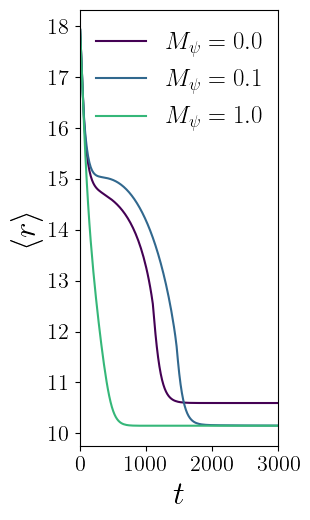

In [8]:
fig, ax = plt.subplots(figsize=(3.2, 5.3), tight_layout=True)
# for m_psi_id in range(len(m_psi_list)):
m_plot_id = [0, 1, -1]
# m_plot_id = [1, -1]
for i in range(len(m_plot_id)):
    m_psi_id = m_plot_id[i]
    ax.plot(
        t_trace_all[m_psi_id],
        r_trace_all[m_psi_id],
        label=f"$M_\\psi={m_psi_list[m_psi_id]:.1f}$",
        color=virimap(i / (len(m_plot_id))),
    )
ax.set_xlabel("$t$")
ax.set_ylabel("$\\langle r \\rangle$")
ax.set_xlim(0, 3000)
ax.set_xticks([0, 1000, 2000, 3000])
ax.legend(frameon=False, loc="upper center", ncol=1, fontsize=18)
fig.savefig(output_folder + "fig2D.pdf", bbox_inches="tight")

# Visualize the dynamics using contours

In [9]:
# define the snapshots to be plotted for each mobility coefficient
t_plot_id_all = [
    np.array([0, 15, 50, 75]),
    np.array([0, 15, 60, 100]),
    np.array([0, 5, 25, 50]),
]

<>:70: SyntaxWarning: invalid escape sequence '\p'
<>:70: SyntaxWarning: invalid escape sequence '\p'
/var/folders/mq/p5kn27bn3j927psc4z_49npm0000gn/T/ipykernel_71893/2851014128.py:70: SyntaxWarning: invalid escape sequence '\p'
  ax_z.set_xlabel("$\psi$")


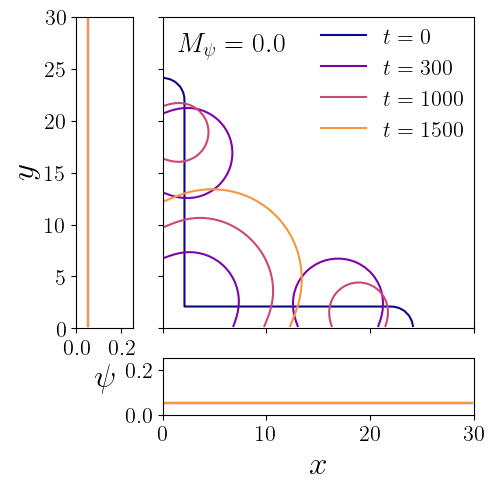

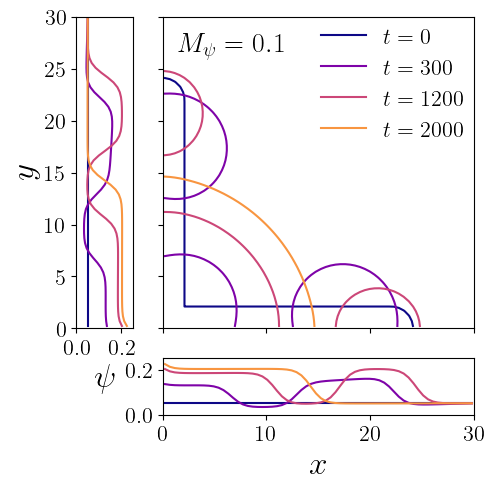

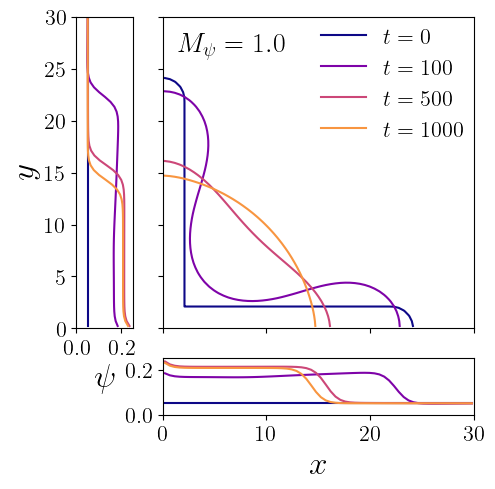

In [10]:
for m_psi_id in range(len(m_psi_list)):
    M_psi = m_psi_list[m_psi_id]
    t_plot_id = t_plot_id_all[m_psi_id]

    data_init_profile = np.load(
        input_folder_name_all[m_psi_id] + "initial_profile.npz",
        allow_pickle=True,
    )
    data_sol_trace = np.load(
        input_folder_name_all[m_psi_id] + "sol_trace.npz",
        allow_pickle=True,
    )
    t_plot = np.array([t_trace_all[m_psi_id][i] for i in t_plot_id])
    t_plot_max = np.max(t_plot)
    colors_plot = [virimap(t_plot[i] / t_plot_max) for i in range(len(t_plot))]
    colors_plot = [plasmamap(i / len(t_plot)) for i in range(len(t_plot))]
    data_plot = [
        (
            data_sol_trace["phi"][t_id],
            data_sol_trace["psi_x"][t_id],
            data_sol_trace["psi_z"][t_id],
        )
        for t_id in t_plot_id
    ]

    phi_contour_plot = []
    for t_id in range(len(data_plot)):
        fig, (ax_img, ax_x, ax_z) = plot_profile(*data_plot[t_id])
        c = ax_img.contour(
            x_center,
            z_center,
            data_plot[t_id][0],
            levels=[phi_binodal_center],
            colors="k",
            linestyles="--",
        )
        plt.close(fig)
        phi_contour_plot.append(c.allsegs[0])

    fig, ax_img = plt.subplots(figsize=(6, 5), tight_layout=True)
    for t_id in range(len(t_plot)):
        for path in phi_contour_plot[t_id]:
            ax_img.plot(
                path[:, 0],
                path[:, 1],
                color=colors_plot[t_id],
                # alpha=0.8,
            )
        ax_img.plot(
            [-1, -1], [-1, -1], color=colors_plot[t_id], label=f"$t={t_plot[t_id]:.0f}$"
        )

    # create side / bottom axes that hug the image axes exactly
    divider = make_axes_locatable(ax_img)
    ax_x = divider.append_axes("bottom", size="18%", pad=0.3, sharex=ax_img)
    ax_z = divider.append_axes("left", size="18%", pad=0.3, sharey=ax_img)

    # Create the second subplot
    for t_id in range(len(t_plot)):
        ax_x.plot(x_center, data_plot[t_id][1], color=colors_plot[t_id])
    ax_x.set_xlabel("$x$")
    # ax_x.set_ylabel("$\psi$")
    ax_x.set_ylim(0, 0.25)
    ax_x.set_yticks([0, 0.2])

    # Create the second subplot
    for t_id in range(len(t_plot)):
        ax_z.plot(data_plot[t_id][2], z_center, color=colors_plot[t_id])
    ax_z.set_ylabel("$y$")
    ax_z.set_xlabel("$\psi$")
    ax_z.set_xlim(0, 0.25)
    ax_z.set_xticks([0, 0.2])

    ax_img.set_xlim(0, flags.Lx)
    ax_img.set_ylim(0, flags.Lz)
    ax_img.set_aspect("equal")

    # remove x‑axis ticks/labels from the main image axis
    ax_img.tick_params(
        axis="x", which="both", bottom=True, top=False, labelbottom=False
    )

    # remove y‑axis ticks/labels from the main image axis
    ax_img.tick_params(axis="y", which="both", left=True, right=False, labelleft=False)

    ax_img.text(
        0.05,
        0.95,
        r"$M_\psi=" + f"{M_psi}$",
        transform=ax_img.transAxes,
        verticalalignment="top",
        fontsize=20,
    )

    ax_img.legend(frameon=False, loc="upper right", ncol=1, bbox_to_anchor=(1.03, 1.03))
    fig.savefig(
        # input_folder_name_all[m_psi_id] + "/phi_contour_vs_t.pdf", bbox_inches="tight"
        output_folder + f"fig2_M_psi_{M_psi:.1f}.pdf",
        bbox_inches="tight",
    )